<a href="https://colab.research.google.com/github/mrudula168/Data-analysis-/blob/main/Best_Streaming_Service_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np # linear algebra
import pandas as pd # data processing

import plotly
import plotly.express as px
from plotly.subplots import make_subplots
import seaborn as sns
import matplotlib.pyplot as plt

# ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [ ]:
tv_shows = pd.read_csv('tv_shows.csv')
tv_shows

,Unnamed: 0,ID,Title,Year,Age,IMDb,Rotten Tomatoes,Netflix,Hulu,Prime Video,Disney+,Type
0,0,1,Breaking Bad,2008,18+,9.4/10,100/100,1,0,0,0,1
1,1,2,Stranger Things,2016,16+,8.7/10,96/100,1,0,0,0,1
2,2,3,Attack on Titan,2013,18+,9.0/10,95/100,1,1,0,0,1
3,3,4,Better Call Saul,2015,18+,8.8/10,94/100,1,0,0,0,1
4,4,5,Dark,2017,16+,8.8/10,93/100,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...
5363,5363,5713,Paradise Islands,2017,NaN,NaN,10/100,0,0,0,1,1
5364,5364,5714,Mexico Untamed,2018,NaN,NaN,10/100,0,0,0,1,1
5365,5365,5715,Wild Centeral America,2020,NaN,NaN,10/100,0,0,0,1,1
5366,5366,5716,Wild Russia,2018,NaN,NaN,10/100,0,0,0,1,1


In [ ]:
tv_shows.head()

,Unnamed: 0,ID,Title,Year,Age,IMDb,Rotten Tomatoes,Netflix,Hulu,Prime Video,Disney+,Type
0,0,1,Breaking Bad,2008,18+,9.4/10,100/100,1,0,0,0,1
1,1,2,Stranger Things,2016,16+,8.7/10,96/100,1,0,0,0,1
2,2,3,Attack on Titan,2013,18+,9.0/10,95/100,1,1,0,0,1
3,3,4,Better Call Saul,2015,18+,8.8/10,94/100,1,0,0,0,1
4,4,5,Dark,2017,16+,8.8/10,93/100,1,0,0,0,1


In [ ]:
tv_shows.shape

(5368, 12)

In [ ]:
tv_shows.columns

Index(['Unnamed: 0', 'ID', 'Title', 'Year', 'Age', 'IMDb', 'Rotten Tomatoes',
       'Netflix', 'Hulu', 'Prime Video', 'Disney+', 'Type'],
      dtype='object')

In [ ]:
tv_shows.dtypes

,0
Unnamed: 0,int64
ID,int64
Title,object
Year,int64
Age,object
IMDb,object
Rotten Tomatoes,object
Netflix,int64
Hulu,int64
Prime Video,int64


In [ ]:
pd.isnull(tv_shows).sum()

,0
Unnamed: 0,0
ID,0
Title,0
Year,0
Age,2127
IMDb,962
Rotten Tomatoes,0
Netflix,0
Hulu,0
Prime Video,0


In [ ]:
tv_shows.drop_duplicates(subset='Title',
                         keep='first',inplace=True)

In [ ]:
tv_shows['Rotten Tomatoes'] = tv_shows['Rotten Tomatoes'].fillna('0%')
# Apply rstrip only if the value is a string
tv_shows['Rotten Tomatoes'] = tv_shows['Rotten Tomatoes'].apply(lambda x: x.rstrip('%') if isinstance(x, str) else x)
# Split the values by '/' and take the first element if it exists, otherwise keep the original value
tv_shows['Rotten Tomatoes'] = tv_shows['Rotten Tomatoes'].apply(lambda x: x.split('/')[0] if '/' in str(x) else x) # Convert to str for '/' check
tv_shows['Rotten Tomatoes'] = pd.to_numeric(tv_shows['Rotten Tomatoes'], errors='coerce') # Handle potential errors with 'coerce'


tv_shows['IMDb'] = tv_shows['IMDb'].fillna(0)
# Extract numeric part of IMDb ratings before multiplying by 10
tv_shows['IMDb'] = tv_shows['IMDb'].astype(str).str.extract('(\d+\.?\d*)').astype(float)
tv_shows['IMDb'] = tv_shows['IMDb']*10
tv_shows['IMDb'] = tv_shows['IMDb'].astype('int')

In [ ]:
tv_shows_long=pd.melt(tv_shows[['Title','Netflix','Hulu','Disney+',
                                'Prime Video']],id_vars=['Title'],
                      var_name='StreamingOn', value_name='Present')
tv_shows_long = tv_shows_long[tv_shows_long['Present'] == 1]
tv_shows_long.drop(columns=['Present'],inplace=True)

In [ ]:
tv_shows_combined = tv_shows_long.merge(tv_shows, on='Title', how='inner')
# Remove 'type' from the list of columns to drop if it doesn't exist
columns_to_drop = ['Unnamed: 0', 'Netflix', 'Hulu', 'Prime Video', 'Disney+']
for column in columns_to_drop:
    if column in tv_shows_combined.columns:
        tv_shows_combined.drop(columns=[column], inplace=True)
# Check if 'type' column exists before dropping
if 'type' in tv_shows_combined.columns:
    tv_shows_combined.drop(columns=['type'], inplace=True)

In [ ]:
tv_shows_combined.head()

,Title,StreamingOn,ID,Year,Age,IMDb,Rotten Tomatoes,Type
0,Breaking Bad,Netflix,1,2008,18+,94,100,1
1,Stranger Things,Netflix,2,2016,16+,87,96,1
2,Attack on Titan,Netflix,3,2013,18+,90,95,1
3,Better Call Saul,Netflix,4,2015,18+,88,94,1
4,Dark,Netflix,5,2017,16+,88,93,1


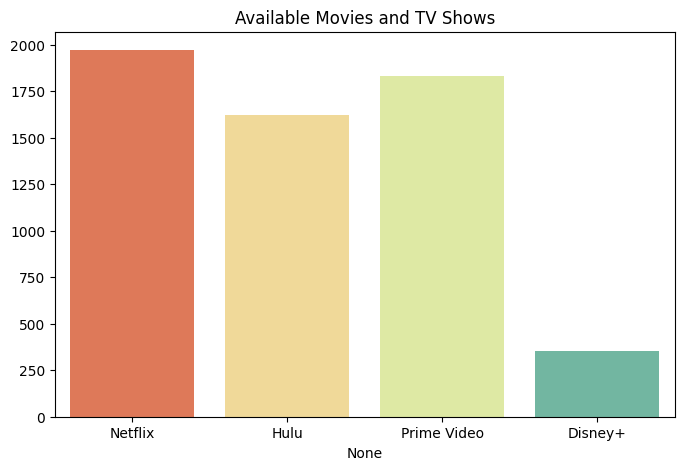

In [ ]:
#Selecting the specific columns from the Dataset and saving into a new dataframe
chosen_columns = ['Netflix', 'Hulu', 'Prime Video', 'Disney+']
platforms_df = tv_shows[chosen_columns]

#Counting all values for each platform
platforms = platforms_df.sum()

#Plotting into a bar plot using Seaborn

plt.figure(figsize=(8,5))
plt.title('Available Movies and TV Shows')

sns.barplot(x=platforms.index, y=platforms.values, palette='Spectral');

([<matplotlib.patches.Wedge at 0x7d6528a4f3d0>,
 [Text(0.28831185046490515, 1.0615442887046693, 'Netflix'),
  Text(-0.9272407577937646, -0.5917977501529094, 'Hulu'),
  Text(0.7586706752659688, -0.7965041158032261, 'Prime Video'),
  Text(1.0971354219521632, -0.07933388870998934, 'Disney+')])

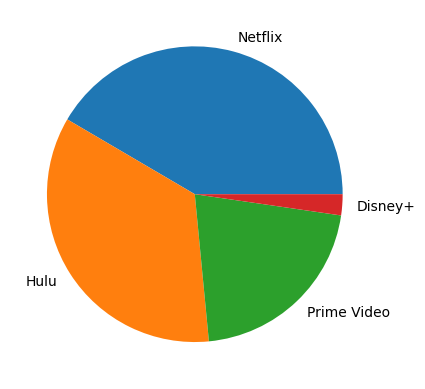

In [ ]:
#Streaming Service Pie-Chart
N = tv_shows['Netflix']
N.head()
Sum= N.sum()
H = tv_shows['Hulu']
H.head()
Hulu_total= H.sum()
P = tv_shows['Prime Video']
P.head()
Prime_total= P.sum()
D= tv_shows['Disney+']
D.head()
Disney_total= D.sum()
show_number =[416,350,212,23]
subs = [('Netflix'),('Hulu'),('Prime Video'),('Disney+')]
plt.pie(show_number,labels=subs)

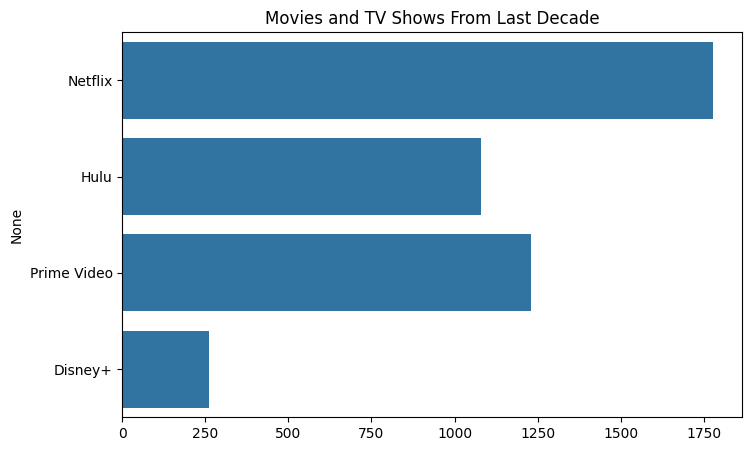

In [ ]:
#filtering movies dating from 2010 beyond
# Replace 'movies_data' with 'tv_shows' if you intend to use the TV shows data.
recent_movies_df = tv_shows.loc[tv_shows.Year > 2010]

#calculating the totals for each column
recent_movies = recent_movies_df[chosen_columns].sum()

#ploting into a barplot using seaborn
plt.figure(figsize=(8,5))
plt.title('Movies and TV Shows From Last Decade')
sns.barplot(x=recent_movies.values, y=recent_movies.index)
plt.show()

<Axes: xlabel='StreamingOn'>

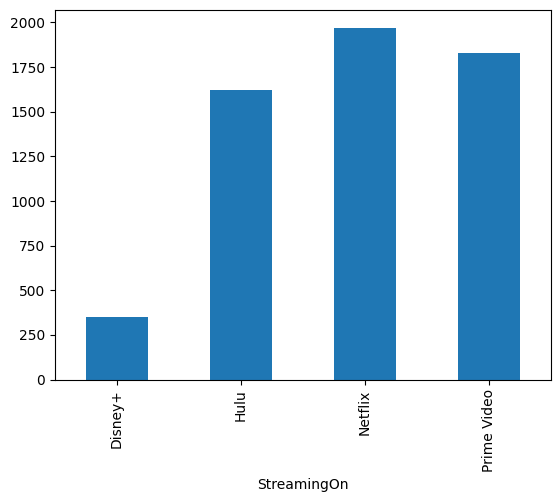

In [ ]:
#the data where the rantings are more than 1 to see the quantity of the tv shows available on each platform
tv_shows_both_ratings = tv_shows_combined[(tv_shows_combined.IMDb > 0) & tv_shows_combined['Rotten Tomatoes'] > 0]
tv_shows_combined.groupby('StreamingOn').Title.count().plot(kind='bar')

In [ ]:
#Analyzing the target age group of most of the TV shows.
#Counting the number of shows for each age classification

# Filter tv_shows_combined to create Hulu_df
Hulu_df = tv_shows_combined[tv_shows_combined['StreamingOn'] == 'Hulu']
# Check if 'Unknown' is present before dropping
if 'Unknown' in Hulu_df.Age.value_counts().index:
    hulu_ages = Hulu_df.Age.value_counts().drop('Unknown')
else:
    hulu_ages = Hulu_df.Age.value_counts()

# Filter tv_shows_combined to create Netflix_df
Netflix_df = tv_shows_combined[tv_shows_combined['StreamingOn'] == 'Netflix']
# Check if 'Unknown' is present before dropping
if 'Unknown' in Netflix_df.Age.value_counts().index:
    netflix_ages = Netflix_df.Age.value_counts().drop('Unknown')
else:
    netflix_ages = Netflix_df.Age.value_counts()

# Filter tv_shows_combined to create PrimeVideo_df
PrimeVideo_df = tv_shows_combined[tv_shows_combined['StreamingOn'] == 'Prime Video']
# Check if 'Unknown' is present before dropping
if 'Unknown' in PrimeVideo_df.Age.value_counts().index:
    primevideo_ages = PrimeVideo_df.Age.value_counts().drop('Unknown')
else:
    primevideo_ages = PrimeVideo_df.Age.value_counts()

# Filter tv_shows_combined to create Disney_df
Disney_df = tv_shows_combined[tv_shows_combined['StreamingOn'] == 'Disney+']
# Check if 'Unknown' is present before dropping
if 'Unknown' in Disney_df.Age.value_counts().index:
    disney_ages = Disney_df.Age.value_counts().drop('Unknown')
else:
    disney_ages = Disney_df.Age.value_counts()

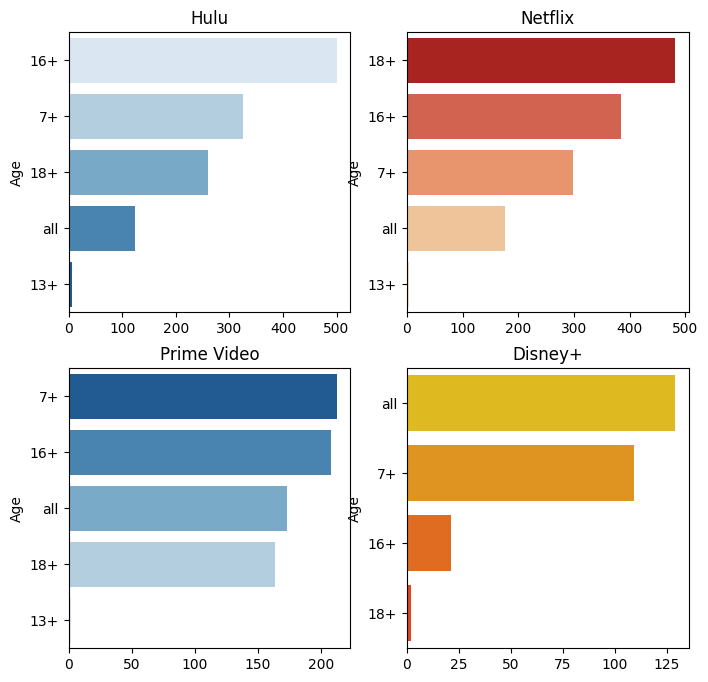

In [ ]:
#Analyzing the target age group of most of the TV shows.

fig, axes = plt.subplots(2,2, figsize=(8, 8))

#setting titles
axes[0,0].set_title('Hulu')
axes[0,1].set_title('Netflix')
axes[1,0].set_title('Prime Video')
axes[1,1].set_title('Disney+')

#plotting the four barplots using seaborn
sns.barplot(x=hulu_ages.values, y=hulu_ages.index, ax=axes[0,0],palette='Blues')
sns.barplot(x=netflix_ages.values, y=netflix_ages.index, ax=axes[0,1], palette='OrRd_r')
sns.barplot(x=primevideo_ages.values, y=primevideo_ages.index, ax=axes[1,0], palette='Blues_r')
sns.barplot(x=disney_ages.values, y=disney_ages.index, ax=axes[1,1], palette='autumn_r')

plt.show()

In [ ]:
#the best streaming service based on their ratings
figure = []
figure.append(px.violin(tv_shows_both_ratings, x = 'StreamingOn', y = 'IMDb', color='StreamingOn'))
figure.append(px.violin(tv_shows_both_ratings, x = 'StreamingOn', y = 'Rotten Tomatoes', color='StreamingOn'))
fig = make_subplots(rows=2, cols=4, shared_yaxes=True)

for i in range(2):
    for j in range(4):
        fig.add_trace(figure[i]['data'][j], row=i+1, col=j+1)

fig.update_layout(autosize=False, width=800, height=800)
fig.show()

In [ ]:
#scatter plot to compare the ratings between IMBD and Rotten Tomatoes to compare which streaming platform has the best ratings in both the user rating platforms
px.scatter(tv_shows_both_ratings, x='IMDb',
           y='Rotten Tomatoes',color='StreamingOn')

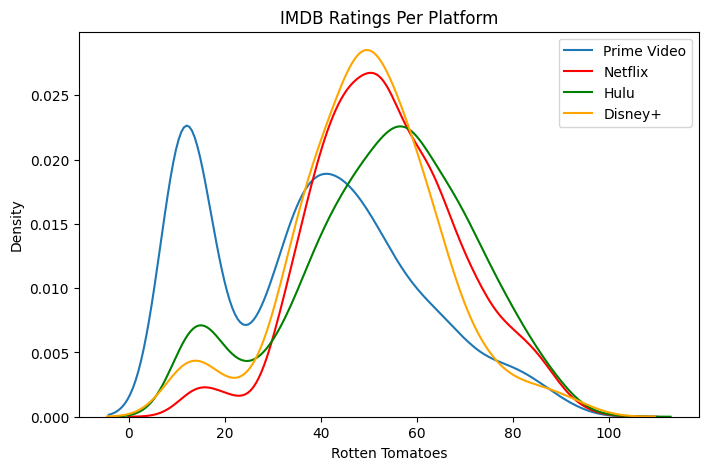

In [ ]:
# Rotten tomatoes per streaming platforms

Hulu_rt = Hulu_df.loc[Hulu_df['Rotten Tomatoes'] > 0 ]
Disney_rt = Disney_df.loc[Disney_df['Rotten Tomatoes'] > 0 ]
PrimeVideo_rt = PrimeVideo_df.loc[PrimeVideo_df['Rotten Tomatoes'] > 0 ]
Netflix_rt = Netflix_df.loc[Netflix_df['Rotten Tomatoes'] > 0 ]

#Defining plot size and title
plt.figure(figsize=(8,5))
plt.title('IMDB Ratings Per Platform')

#Plotting the information from each dataset into a KDE plot
sns.kdeplot(data=PrimeVideo_rt['Rotten Tomatoes'],  legend=True)
sns.kdeplot(data=Netflix_rt['Rotten Tomatoes'], color='red',  legend=True)
sns.kdeplot(data=Hulu_rt['Rotten Tomatoes'], color='green',  legend=True)
sns.kdeplot(data=Disney_rt['Rotten Tomatoes'], color='orange', legend=True)

#Setting the legend
plt.legend(['Prime Video', 'Netflix', 'Hulu', 'Disney+'])
plt.show()

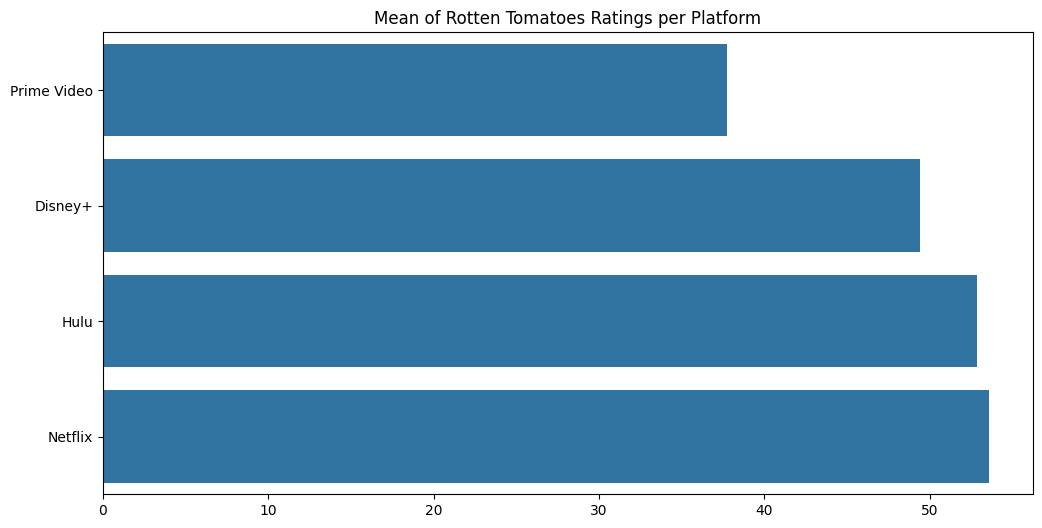

In [ ]:
Means_rt = {}
# Creating dataframes for Rotten Tomatoes ratings
Hulu_rotten_tomatoes = Hulu_df.loc[Hulu_df['Rotten Tomatoes'] > 0]
Disney_rotten_tomatoes = Disney_df.loc[Disney_df['Rotten Tomatoes'] > 0]
PrimeVideo_rotten_tomatoes = PrimeVideo_df.loc[PrimeVideo_df['Rotten Tomatoes'] > 0]
Netflix_rotten_tomatoes = Netflix_df.loc[Netflix_df['Rotten Tomatoes'] > 0]


#obtaining the mean for the IMDb column in each dataset
Means_rt['Prime Video'] = PrimeVideo_rotten_tomatoes['Rotten Tomatoes'].mean()
Means_rt['Disney+'] = Disney_rotten_tomatoes['Rotten Tomatoes'].mean()
Means_rt['Hulu'] = Hulu_rotten_tomatoes['Rotten Tomatoes'].mean()
Means_rt['Netflix'] = Netflix_rotten_tomatoes['Rotten Tomatoes'].mean()

#plotting a horizontal bar and defining figure size, title and xticks
plt.figure(figsize=(12,6))

sns.barplot(y=list(Means_rt.keys()), x=list(Means_rt.values()))
plt.title('Mean of Rotten Tomatoes Ratings per Platform')

plt.show()

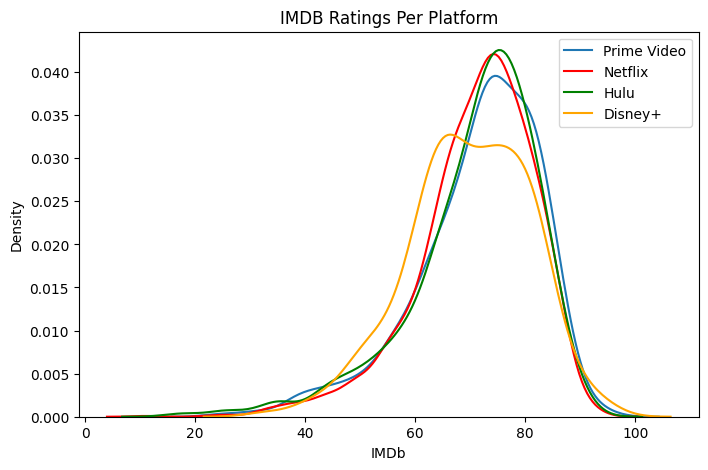

In [ ]:
#Creating distinct dataframes only with the movies present on individual streaming platforms

Hulu_imdb = Hulu_df.loc[Hulu_df['IMDb'] > 0 ]
Disney_imdb = Disney_df.loc[Disney_df['IMDb'] > 0 ]
PrimeVideo_imdb = PrimeVideo_df.loc[PrimeVideo_df['IMDb'] > 0 ]
Netflix_imdb = Netflix_df.loc[Netflix_df['IMDb'] > 0 ]

#Defining plot size and title
plt.figure(figsize=(8,5))
plt.title('IMDB Ratings Per Platform')

#Plotting the information from each dataset into a KDE plot
sns.kdeplot(data=PrimeVideo_imdb['IMDb'],  legend=True)
sns.kdeplot(data=Netflix_imdb['IMDb'], color='red',  legend=True)
sns.kdeplot(data=Hulu_imdb['IMDb'], color='green',  legend=True)
sns.kdeplot(data=Disney_imdb['IMDb'], color='orange', legend=True)

#Setting the legend
plt.legend(['Prime Video', 'Netflix', 'Hulu', 'Disney+'])
plt.show()